In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import nltk
from google.colab import drive
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizerFast
from transformers import TFRobertaModel
import tensorflow as tf
from tensorflow import keras
from tf_keras.src.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files
import shutil
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.metrics import classification_report
from sklearn.utils import class_weight

seed=42

In [2]:
df = pd.read_csv('daftar_topik_ldanew2.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0.1     20000 non-null  int64 
 1   Unnamed: 0       20000 non-null  int64 
 2   userName         20000 non-null  object
 3   content          20000 non-null  object
 4   score            20000 non-null  int64 
 5   at               20000 non-null  object
 6   appVersion       20000 non-null  object
 7   casefolding      20000 non-null  object
 8   text_cleaned     19991 non-null  object
 9   slang            19991 non-null  object
 10  stopwords        19982 non-null  object
 11  sentiment_label  20000 non-null  object
 12  word_count       20000 non-null  int64 
 13  dominant_topic   20000 non-null  int64 
 14  char_len         20000 non-null  int64 
 15  slang_len        20000 non-null  int64 
 16  over_repeated    20000 non-null  bool  
 17  repeated_words   20000 non-null

In [3]:
df = df[['slang2', 'dominant_topic']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   slang2          19991 non-null  object
 1   dominant_topic  20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [4]:
df.head()

,slang2,dominant_topic
0,mencari driver sampai setengah jam lebih tidak...,1
1,sistem gojek aneh aplikasi gojek tidak pernah ...,2
2,kepada yang terhormat pimpinan gojek akhir akh...,1
3,wahai kastamer anda sadar tidak memberi bintan...,1
4,kecewa pesanan saya tidak lengkap saya memesan...,1


In [5]:
df['dominant_topic'].value_counts()

,count
dominant_topic,
4,4660
1,4636
2,4239
0,3451
3,3014


In [4]:
label_map = {
    "Kenaikan Biaya dan Penurunan Manfaat promo GoFood" : 0,
    "Masalah Driver & Layanan (Ketersediaan, Profesionalitas, Keselamatan)" : 1,
    "Masalah Akun, Gopay, Paylater, dan Sistem Transaksi" : 2,
    "Pujian dan Kepuasan Pengguna" : 3,
    "Masalah performa dan stabilitas aplikasi Gojek": 4
}

df["dominant_topic"] = df["dominant_topic"].map(label_map)


In [5]:
df.head()

,slang2,dominant_topic
0,mencari driver sampai setengah jam lebih tidak...,NaN
1,sistem gojek aneh aplikasi gojek tidak pernah ...,NaN
2,kepada yang terhormat pimpinan gojek akhir akh...,NaN
3,wahai kastamer anda sadar tidak memberi bintan...,NaN
4,kecewa pesanan saya tidak lengkap saya memesan...,NaN


In [6]:
df['dominant_topic'].value_counts()

,count
dominant_topic,
4,4660
1,4636
2,4239
0,3451
3,3014


In [6]:
x = df['slang2'].values
y = df['dominant_topic'].values

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=seed)

X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.1 / 0.9, stratify=y_temp, random_state=seed)

In [8]:
y_train_le = y_train.copy()
y_valid_le = y_valid.copy()
y_test_le = y_test.copy()

In [9]:
ohe = preprocessing.OneHotEncoder()
y_train = ohe.fit_transform(np.array(y_train).reshape(-1, 1)).toarray()
y_valid = ohe.fit_transform(np.array(y_valid).reshape(-1, 1)).toarray()
y_test = ohe.fit_transform(np.array(y_test).reshape(-1, 1)).toarray()

In [10]:
print(f"TRAINING DATA: {X_train.shape[0]}\nVALIDATION DATA: {X_valid.shape[0]}\nTESTING DATA: {X_test.shape[0]}" )

TRAINING DATA: 15999
VALIDATION DATA: 2001
TESTING DATA: 2000


In [11]:
tokenizer_roberta = RobertaTokenizerFast.from_pretrained("roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [12]:
def tokenize_roberta(data, max_len):
    input_ids = []
    attention_masks = []

    for text in data:
        encoded = tokenizer_roberta.encode_plus(
            str(text),
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)

In [13]:
tokenizer_roberta_indo = RobertaTokenizerFast.from_pretrained("cahya/roberta-base-indonesian-1.5G")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

In [14]:
def tokenize_roberta_indo(data, max_len):
    input_ids = []
    attention_masks = []

    for text in data:
        encoded = tokenizer_roberta_indo.encode_plus(
            str(text),
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)

In [13]:
MAX_LEN=128

In [14]:
X_train = X_train.astype(str)
X_test = X_test.astype(str)

In [15]:
train_input_ids, train_attention_masks = tokenize_roberta(X_train, MAX_LEN)
val_input_ids, val_attention_masks = tokenize_roberta(X_valid, MAX_LEN)
test_input_ids, test_attention_masks = tokenize_roberta(X_test, MAX_LEN)

In [17]:
train_input_ids, train_attention_masks = tokenize_roberta_indo(X_train, MAX_LEN)
val_input_ids, val_attention_masks = tokenize_roberta_indo(X_valid, MAX_LEN)
test_input_ids, test_attention_masks = tokenize_roberta_indo(X_test, MAX_LEN)

In [18]:
class WarmupLinearDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, total_steps, end_lr=0.0, name="WarmupLinearDecay"):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.end_lr = end_lr
        self.name = name

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        warmup_lr = self.initial_lr * (step / self.warmup_steps)
        decay_lr = self.initial_lr - (
            (self.initial_lr - self.end_lr)
            * ((step - self.warmup_steps) /
               (self.total_steps - self.warmup_steps))
        )

        return tf.cond(step < self.warmup_steps,
                       lambda: warmup_lr,
                       lambda: decay_lr)

    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "end_lr": self.end_lr,
            "name": self.name,
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
)

In [17]:
print(y_train[:5])
print(y_train.shape)

[[0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]
(15999, 5)


In [18]:
BATCH_SIZE = 32
EPOCHS = 8

In [19]:
train_steps_per_epoch = len(train_input_ids) // BATCH_SIZE
total_steps = train_steps_per_epoch * EPOCHS

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

# **RoBERTa-base VS RoBERTa-Base-Indonesian 1.5G**

# 1. RoBERTa-Base

## **Baseline RoBERTa (RoBERTa Batch Size 32, Learning Rate 1e-5, Adam Optimizer(RoBERTa-Base))**

In [20]:
roberta_model = TFRobertaModel.from_pretrained("roberta-base", from_pt=True)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.decoder.weight', 'lm_head.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.bias', 'lm_head.bias']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFRobertaModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint 

In [21]:
def create_model(roberta_model, max_len=MAX_LEN):

    opt = tf.keras.optimizers.Adam(learning_rate=1e-5)
    loss = tf.keras.losses.CategoricalCrossentropy()
    accuracy = tf.keras.metrics.CategoricalAccuracy()

    input_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_masks = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

    outputs = roberta_model([input_ids, attention_masks])
    pooled_output = outputs[1]

    sentiment_output = tf.keras.layers.Dense(5, activation='softmax', name="aspect_output")(pooled_output)

    model = tf.keras.models.Model(
        inputs=[input_ids, attention_masks],
        outputs=sentiment_output
    )

    model.compile(optimizer=opt, loss=loss, metrics=[accuracy])

    return model

In [23]:
model = create_model(roberta_model, MAX_LEN)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1246456   ['input_ids[0][0]',           
 aModel)                     ngAndCrossAttentions(last_   32         'attention_mask[0][0]']      
                             hidden_state=(None, 128, 7                                       

In [24]:
print(y_train[:5])
print(y_train.shape)

[[0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]
(15999, 5)


In [25]:
y_train_int = np.argmax(y_train, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.1589279246649764), 1: np.float64(0.8629449838187703), 2: np.float64(0.9436154526688293), 3: np.float64(1.3271671505599336), 4: np.float64(0.8583154506437768)}


In [26]:
history_aspect = model.fit([train_input_ids,train_attention_masks], y_train, validation_data=([val_input_ids,val_attention_masks], y_valid), epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights, callbacks=[early_stop])

Epoch 1/8
500/500 [==============================] - 512s 854ms/step - loss: 0.8925 - categorical_accuracy: 0.6480 - val_loss: 0.6616 - val_categorical_accuracy: 0.7586
Epoch 2/8
500/500 [==============================] - 414s 828ms/step - loss: 0.5950 - categorical_accuracy: 0.7819 - val_loss: 0.5986 - val_categorical_accuracy: 0.7861
Epoch 3/8
500/500 [==============================] - 413s 825ms/step - loss: 0.4994 - categorical_accuracy: 0.8166 - val_loss: 0.5745 - val_categorical_accuracy: 0.7971
Epoch 4/8
500/500 [==============================] - 413s 826ms/step - loss: 0.4280 - categorical_accuracy: 0.8426 - val_loss: 0.5362 - val_categorical_accuracy: 0.8161
Epoch 5/8
500/500 [==============================] - 412s 824ms/step - loss: 0.3690 - categorical_accuracy: 0.8660 - val_loss: 0.5560 - val_categorical_accuracy: 0.8276
Epoch 6/8
500/500 [==============================] - 413s 825ms/step - loss: 0.3257 - categorical_accuracy: 0.8798 - val_loss: 0.5916 - val_categorical_acc

In [27]:
result_roberta = model.predict([test_input_ids,test_attention_masks])

63/63 [==============================] - 20s 272ms/step


In [28]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

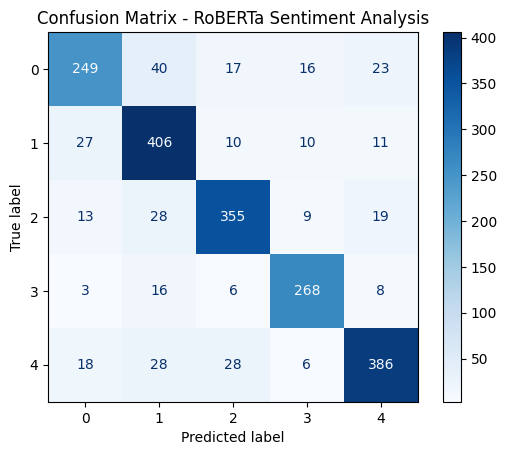

In [29]:
y_test_labels = y_test.argmax(axis=1)
y_pred_labels = y_pred_roberta.argmax(axis=1)

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['0', '1', '2', '3', '4'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - RoBERTa Sentiment Analysis')
plt.show()

In [30]:
print('\tClassification Report for RoBERTa:\n\n',classification_report(y_test,y_pred_roberta, target_names=['Biaya dan Promosi', 'Pelayanan Driver', 'Akun dan Fungsionalitas Sistem', 'Kepuasan dan Keamanan Layanan', 'Performa dan Stabilitas Aplikasi'], digits=4))

	Classification Report for RoBERTa:

                                   precision    recall  f1-score   support

               Biaya dan Promosi     0.8032    0.7217    0.7603       345
                Pelayanan Driver     0.7838    0.8750    0.8269       464
  Akun dan Fungsionalitas Sistem     0.8534    0.8373    0.8452       424
   Kepuasan dan Keamanan Layanan     0.8673    0.8904    0.8787       301
Performa dan Stabilitas Aplikasi     0.8635    0.8283    0.8456       466

                       micro avg     0.8320    0.8320    0.8320      2000
                       macro avg     0.8342    0.8305    0.8313      2000
                    weighted avg     0.8330    0.8320    0.8314      2000
                     samples avg     0.8320    0.8320    0.8320      2000



In [ ]:
def predict_aspect(text):
    input_ids, attention_masks = tokenize_roberta([text], MAX_LEN)

    predictions = model.predict([input_ids, attention_masks], verbose=0)
    predicted_class = np.argmax(predictions, axis=1)[0]

    label_map = {0: "Biaya dan Promosi", 1: "Pelayanan Driver", 2: "Akun dan Fungsionalitas Sistem", 3: "Kepuasan dan Keamanan Layanan", 4: "Performa dan Stabilitas Aplikasi"}

    return label_map[predicted_class], predictions[0]

In [ ]:
tests = [
    "Promo Gojeknya sangat membantu, harganya juga murah.",
    "Driver-nya ramah dan cepat respon.",
    "Aplikasi sering error waktu buka GoPay.",
    "Layanan aman dan memuaskan, mantap!",
    "Tolong perbaiki bug di update terbaru.",
]

for text in tests:
    label, score = predict_aspect(text)
    print(f"Teks: {text}")
    print(f"Aspek: {label}")
    print(f"Probabilitas: {score}\n")


Teks: Promo Gojeknya sangat membantu, harganya juga murah.
Aspek: Biaya dan Promosi
Probabilitas: [0.6087057  0.37633178 0.00290393 0.00897932 0.00307922]

Teks: Driver-nya ramah dan cepat respon.
Aspek: Pelayanan Driver
Probabilitas: [0.00880719 0.9623049  0.01005856 0.00209925 0.01673017]

Teks: Aplikasi sering error waktu buka GoPay.
Aspek: Performa dan Stabilitas Aplikasi
Probabilitas: [0.02998218 0.05432262 0.05457114 0.02146257 0.8396615 ]

Teks: Layanan aman dan memuaskan, mantap!
Aspek: Kepuasan dan Keamanan Layanan
Probabilitas: [9.5558615e-04 2.0979594e-04 3.7085733e-04 9.9822336e-01 2.4038249e-04]

Teks: Tolong perbaiki bug di update terbaru.
Aspek: Performa dan Stabilitas Aplikasi
Probabilitas: [0.0125212  0.0267262  0.07015932 0.01921202 0.8713813 ]



# 2. RoBERTa-Base-Indonesian 1.5G

In [23]:
indo_roberta_model = TFRobertaModel.from_pretrained("cahya/roberta-base-indonesian-1.5G", from_pt=True)

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaModel: ['lm_head.bias', 'lm_head.decoder.bias', 'lm_head.decoder.weight', 'lm_head.layer_norm.weight', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.bias', 'lm_head.dense.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing TFRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaModel were not initialized 

In [24]:
def create_model(roberta_model, max_len=MAX_LEN):

    opt = tf.keras.optimizers.Adam(learning_rate=1e-5)
    loss = tf.keras.losses.CategoricalCrossentropy()
    accuracy = tf.keras.metrics.CategoricalAccuracy()

    input_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_masks = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

    outputs = roberta_model([input_ids, attention_masks])
    pooled_output = outputs[1]

    sentiment_output = tf.keras.layers.Dense(5, activation='softmax', name="aspect_output")(pooled_output)

    model = tf.keras.models.Model(
        inputs=[input_ids, attention_masks],
        outputs=sentiment_output
    )

    model.compile(optimizer=opt, loss=loss, metrics=[accuracy])

    return model

In [25]:
model = create_model(indo_roberta_model, MAX_LEN)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1259781   ['input_ids[0][0]',           
 aModel)                     ngAndCrossAttentions(last_   12         'attention_mask[0][0]']      
                             hidden_state=(None, 128, 7                                       

In [29]:
history_aspect = model.fit([train_input_ids,train_attention_masks], y_train, validation_data=([val_input_ids,val_attention_masks], y_valid), epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights, callbacks=[early_stop])

Epoch 1/8
500/500 [==============================] - 482s 849ms/step - loss: 0.6817 - categorical_accuracy: 0.7492 - val_loss: 0.5461 - val_categorical_accuracy: 0.7986
Epoch 2/8
500/500 [==============================] - 410s 820ms/step - loss: 0.4282 - categorical_accuracy: 0.8466 - val_loss: 0.4957 - val_categorical_accuracy: 0.8216
Epoch 3/8
500/500 [==============================] - 410s 819ms/step - loss: 0.3158 - categorical_accuracy: 0.8854 - val_loss: 0.5099 - val_categorical_accuracy: 0.8236
Epoch 4/8
500/500 [==============================] - 409s 818ms/step - loss: 0.2178 - categorical_accuracy: 0.9217 - val_loss: 0.5751 - val_categorical_accuracy: 0.8221


In [30]:
result_roberta = model.predict([test_input_ids,test_attention_masks])

63/63 [==============================] - 20s 272ms/step


In [31]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

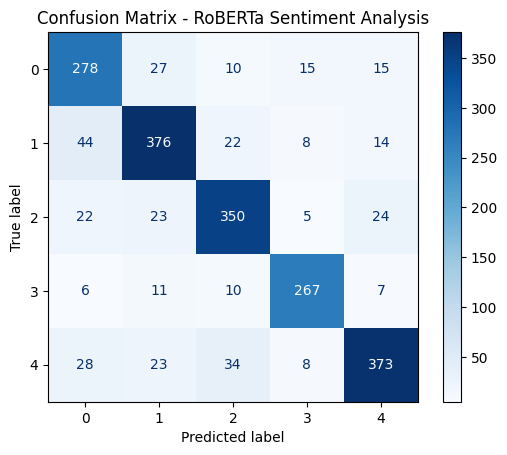

In [32]:
y_test_labels = y_test.argmax(axis=1)
y_pred_labels = y_pred_roberta.argmax(axis=1)

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['0', '1', '2', '3', '4'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - RoBERTa Sentiment Analysis')
plt.show()

In [33]:
print('\tClassification Report for RoBERTa:\n\n',classification_report(y_test,y_pred_roberta, target_names=['Kenaikan Biaya dan Penurunan Manfaat promo GoFood', 'Masalah Driver & Layanan (Ketersediaan, Profesionalitas, Keselamatan)', 'Masalah Akun, Gopay, Paylater, dan Sistem Transaksi', 'Pujian dan Kepuasan Pengguna', 'Masalah performa dan stabilitas aplikasi Gojek'], digits=4))

	Classification Report for RoBERTa:

                                                                        precision    recall  f1-score   support

                    Kenaikan Biaya dan Penurunan Manfaat promo GoFood     0.7354    0.8058    0.7690       345
Masalah Driver & Layanan (Ketersediaan, Profesionalitas, Keselamatan)     0.8174    0.8103    0.8139       464
                  Masalah Akun, Gopay, Paylater, dan Sistem Transaksi     0.8216    0.8255    0.8235       424
                                         Pujian dan Kepuasan Pengguna     0.8812    0.8870    0.8841       301
                    Masalah performa dan stabilitas aplikasi Gojek":      0.8614    0.8004    0.8298       466

                                                            micro avg     0.8220    0.8220    0.8220      2000
                                                            macro avg     0.8234    0.8258    0.8241      2000
                                                         weighted avg   

## **(RoBERTa Batch Size 32, Learning Rate 1e-5, Warmup Ratio 10%, AdamW Optimizer(RoBERTa-Base-Indonesian 1.5G))**

In [34]:
def create_model(bert_model, max_len=MAX_LEN):
    initial_lr = 1e-5
    warmup_ratio = 0.1
    warmup_steps = int(total_steps * warmup_ratio)

    lr_schedule = WarmupLinearDecay(
        initial_lr=initial_lr,
        warmup_steps=warmup_steps,
        total_steps=total_steps,
        end_lr=0.0
    )

    opt = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=0.01
    )

    loss = tf.keras.losses.CategoricalCrossentropy()
    accuracy = tf.keras.metrics.CategoricalAccuracy()

    input_ids = tf.keras.Input(shape=(max_len,), dtype='int32')
    attention_masks = tf.keras.Input(shape=(max_len,), dtype='int32')

    bert_output = bert_model([input_ids, attention_masks])
    pooled_output = bert_output[1]

    x = tf.keras.layers.Dropout(0.1)(pooled_output)
    logits = tf.keras.layers.Dense(5, activation="softmax")(x)

    model = tf.keras.Model(inputs=[input_ids, attention_masks], outputs=logits)

    model.compile(optimizer=opt, loss=loss, metrics=[accuracy])
    return model

In [36]:
model = create_model(indo_roberta_model, MAX_LEN)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128)]                0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 128)]                0         []                            
                                                                                                  
 tf_roberta_model (TFRobert  TFBaseModelOutputWithPooli   1259781   ['input_1[0][0]',             
 aModel)                     ngAndCrossAttentions(last_   12         'input_2[0][0]']             
                             hidden_state=(None, 128, 7                                           
                             68),                                                           

In [37]:
history_aspect = model.fit([train_input_ids,train_attention_masks], y_train, validation_data=([val_input_ids,val_attention_masks], y_valid), epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights, callbacks=[early_stop])

Epoch 1/8
500/500 [==============================] - 545s 863ms/step - loss: 0.5600 - categorical_accuracy: 0.7887 - val_loss: 0.5221 - val_categorical_accuracy: 0.8226
Epoch 2/8
500/500 [==============================] - 418s 837ms/step - loss: 0.2822 - categorical_accuracy: 0.8991 - val_loss: 0.5081 - val_categorical_accuracy: 0.8351
Epoch 3/8
500/500 [==============================] - 418s 836ms/step - loss: 0.1838 - categorical_accuracy: 0.9367 - val_loss: 0.5788 - val_categorical_accuracy: 0.8341
Epoch 4/8
500/500 [==============================] - 418s 836ms/step - loss: 0.1157 - categorical_accuracy: 0.9602 - val_loss: 0.6384 - val_categorical_accuracy: 0.8386


In [38]:
result_roberta = model.predict([test_input_ids,test_attention_masks])

63/63 [==============================] - 20s 273ms/step


In [39]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

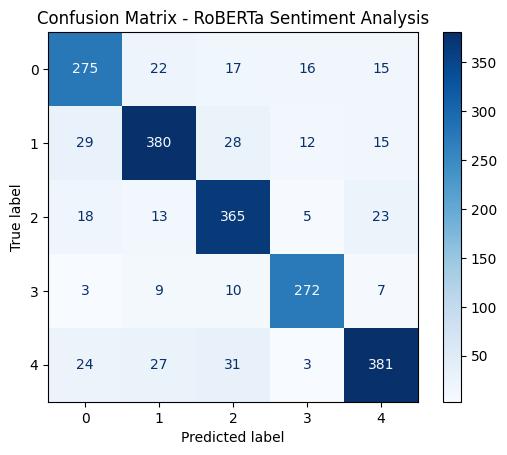

In [40]:
y_test_labels = y_test.argmax(axis=1)
y_pred_labels = y_pred_roberta.argmax(axis=1)

conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['0', '1', '2', '3', '4'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix - RoBERTa Sentiment Analysis')
plt.show()

In [41]:
print('\tClassification Report for RoBERTa:\n\n',classification_report(y_test,y_pred_roberta, target_names=['Kenaikan Biaya dan Penurunan Manfaat promo GoFood', 'Masalah Driver & Layanan (Ketersediaan, Profesionalitas, Keselamatan)', 'Masalah Akun, Gopay, Paylater, dan Sistem Transaksi', 'Pujian dan Kepuasan Pengguna', 'Masalah performa dan stabilitas aplikasi Gojek'], digits=4))

	Classification Report for RoBERTa:

                                                                        precision    recall  f1-score   support

                    Kenaikan Biaya dan Penurunan Manfaat promo GoFood     0.7880    0.7971    0.7925       345
Masalah Driver & Layanan (Ketersediaan, Profesionalitas, Keselamatan)     0.8426    0.8190    0.8306       464
                  Masalah Akun, Gopay, Paylater, dan Sistem Transaksi     0.8093    0.8608    0.8343       424
                                         Pujian dan Kepuasan Pengguna     0.8831    0.9037    0.8933       301
                       Masalah performa dan stabilitas aplikasi Gojek     0.8639    0.8176    0.8401       466

                                                            micro avg     0.8365    0.8365    0.8365      2000
                                                            macro avg     0.8374    0.8396    0.8382      2000
                                                         weighted avg   

In [42]:
y_pred_roberta =  np.zeros_like(result_roberta)
y_pred_roberta[np.arange(len(y_pred_roberta)), result_roberta.argmax(1)] = 1

In [43]:
from google.colab import files
import os
import shutil

save_dir = "/content/roberta_save"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "roberta_aspect_model.h5")
model.save(model_path, include_optimizer=False)
print(f"Model disimpan di: {model_path}")

tokenizer_path = os.path.join(save_dir, "roberta_tokenizer")
tokenizer_roberta_indo.save_pretrained(tokenizer_path)

files.download(model_path)

zip_path = "/content/roberta_tokenizer.zip"
shutil.make_archive("/content/roberta_tokenizer", 'zip', tokenizer_path)
files.download(zip_path)

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model disimpan di: /content/roberta_save/roberta_aspect_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
save_dir = "/content/drive/MyDrive/SKRIPSI/aspect"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "roberta_aspect_model.keras")
model.save(model_path)
print(f"Model disimpan dalam format .keras di: {model_path}")

tokenizer_path = os.path.join(save_dir, "roberta_aspect_tokenizer")
tokenizer_roberta.save_pretrained(tokenizer_path)
print(f"Tokenizer disimpan di: {tokenizer_path}")

Model disimpan dalam format .keras di: /content/drive/MyDrive/SKRIPSI/aspect/roberta_aspect_model.keras
Tokenizer disimpan di: /content/drive/MyDrive/SKRIPSI/aspect/roberta_aspect_tokenizer


In [ ]:
import os

save_dir = "/content/roberta_aspect"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "roberta_aspect_model.keras")
model.save(model_path)
print(f"Model disimpan di: {model_path}")

tokenizer_path = os.path.join(save_dir, "roberta_aspect_tokenizer")
tokenizer_roberta.save_pretrained(tokenizer_path)
print(f"Tokenizer disimpan di: {tokenizer_path}")

Model disimpan di: /content/roberta_aspect/roberta_aspect_model.keras
Tokenizer disimpan di: /content/roberta_aspect/roberta_aspect_tokenizer


In [ ]:
import shutil
from google.colab import files

shutil.make_archive("roberta_aspect", 'zip', "/content/roberta_aspect")

files.download("/content/roberta_aspect.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>